# Stimulus omission responses at different flash rates

This notebook generates the plots for Supplementary Figure 2, which showcases the omission stimulus responses of the model at different flash rates.

In [490]:
import os

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [491]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

In [492]:
def plot_osr(ors_query, intesity_ax, max_r, idx, d, firing_ax):
    # Intensity plot
    intesity_ax.plot(ors_query.flash_clip, c="black", linewidth=2)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    fs = 20
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    intesity_ax.set_yticks([0, 1])
    intesity_ax.set_xlim([0, len(ors_query.flash_clip)])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    intesity_ax.set_ylabel("Intensity", fontsize=fs, labelpad=35, rotation=0)
    
    # Firing rate plot
    firing_ax.plot([388-d, 388-d], [0, 1], "--", c="black", linewidth=2)
    firing_ax.plot(ors_query.firing_rate[idx], linewidth=3) # 58
    firing_ax.set_xticks([0, 36, 36+120, 36+2*120, 36+3*120])
    firing_ax.set_xticklabels(["", "0", "0.5", "1.0", "1.5"]) 
    
    firing_ax.spines["top"].set_visible(False)
    firing_ax.spines["right"].set_visible(False)
    firing_ax.spines["bottom"].set_linewidth(2)
    firing_ax.spines["left"].set_linewidth(2)
    firing_ax.set_xlim([0, len(ors_query.flash_clip)])
    firing_ax.set_ylim([0, max_r])
    firing_ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    
    firing_ax.set_yticks([0, max_r])
    firing_ax.set_yticklabels(["0", f"{int(max_r * (240))}"])
    firing_ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
    firing_ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=10)

## 16Hz OSR

In [493]:
ors_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16)

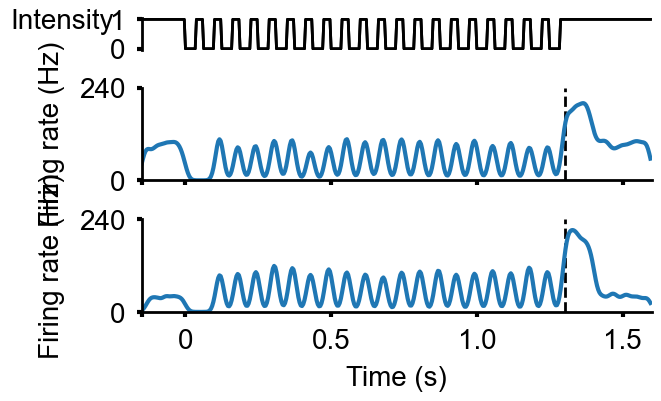

In [494]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1
plot_osr(ors_query_16hz, intesity_ax, 1, ors_query_16hz.OSR_idx[0], d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_16hz, intesity_ax, 1, ors_query_16hz.OSR_idx[1], d, firing2_ax)
plt.savefig(f"{root}/figures/supp/16hz.svg", format="svg", transparent=False, bbox_inches="tight")

In [495]:
print(f"prediction model, % units with osr={(len(ors_query_16hz.OSR_idx)/400)*100}")

prediction model, % units with osr=7.249999999999999


## 8Hz OSR

In [496]:
ors_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8)

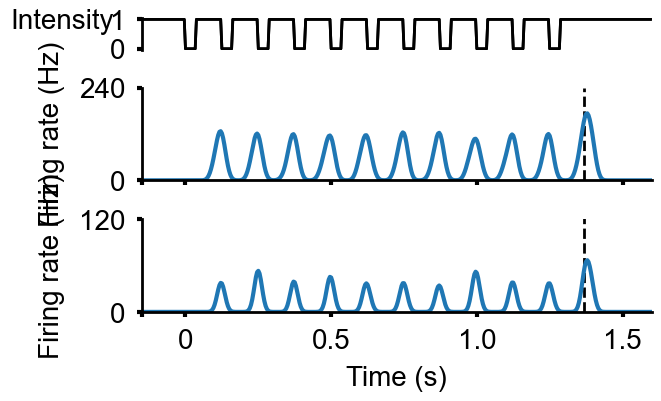

In [497]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-30+9+1
plot_osr(ors_query_8hz, intesity_ax, 1, ors_query_8hz.OSR_idx[2], d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_8hz, intesity_ax, 0.5, ors_query_8hz.OSR_idx[0], d, firing2_ax)
plt.savefig(f"{root}/figures/supp/8hz.svg", format="svg", transparent=False, bbox_inches="tight")

In [498]:
print(f"prediction model, % units with osr={(len(ors_query_8hz.OSR_idx)/400)*100}")

prediction model, % units with osr=1.5


## 16 Hz with middle of the sequence omission

In [499]:
ors_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)

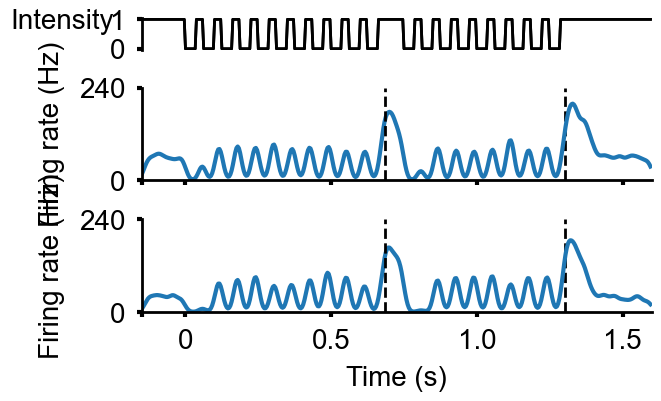

In [502]:
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1
plot_osr(ors_query_mid_16hz, intesity_ax, 1, ors_query_mid_16hz.OSR_idx[3], d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_mid_16hz, intesity_ax, 1, ors_query_mid_16hz.OSR_idx[1], d, firing2_ax)
firing1_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
firing2_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
plt.savefig(f"{root}/figures/supp/mid_16hz.svg", format="svg", transparent=False, bbox_inches="tight")